In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# from google.colab import data_table
# data_table.enable_dataframe_formatter()

print("Libraries loaded as expected")

Libraries loaded as expected


In [3]:
df = pd.read_csv('Planetary_data.csv', comment='#')

In [17]:
### Kepler telescope searches for faraway exoplanets whereas TESS looks for in the surrounding neighbourhood.
#### Let's see if data is matching the theory or are there any discrepencies.


only_kepler_data = df[df['pl_name'].str.contains('Kepler')]
kepler_data = only_kepler_data['sy_dist'].median()
print(kepler_data)

760.708


In [19]:
only_toi_data = df[df['pl_name'].str.contains('TOI')]
toi_data = only_toi_data['sy_dist'].median()
print(toi_data)

116.086


<Axes: xlabel='Survey strategies', ylabel='Distance in parsecs'>

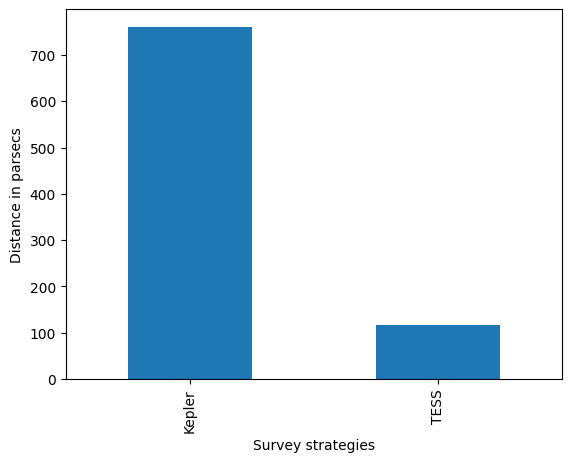

In [21]:
comparison = pd.Series({'Kepler': kepler_data, 'TESS': toi_data})
comparison.plot(kind='bar', ylabel="Distance in parsecs", xlabel="Survey strategies")

In [34]:
raw_df = df.dropna(subset=['st_spectype']).copy()
raw_df['star_class'] = raw_df['st_spectype'].str[0]
filtered = raw_df[raw_df['star_class'].isin(['O', 'B', 'A', 'F', 'G', 'K', 'M'])]

In [44]:
pd.pivot_table(filtered, index=raw_df['star_class'], columns=raw_df['discoverymethod'], aggfunc='size', fill_value=0)

discoverymethod,Astrometry,Disk Kinematics,Eclipse Timing Variations,Imaging,Microlensing,Orbital Brightness Modulation,Pulsation Timing Variations,Radial Velocity,Transit,Transit Timing Variations
star_class,,,,,,,,,,
A,0,0,0,12,0,0,1,1,10,0
B,0,1,0,6,0,2,0,0,1,0
F,0,0,1,7,1,1,0,89,183,5
G,0,0,0,4,6,0,0,434,331,6
K,0,0,0,15,8,0,0,354,269,3
M,1,0,1,29,13,0,0,184,322,4


In [43]:
# pivot_data.style.background_gradient(cmap='Greens')

discoverymethod,Astrometry,Disk Kinematics,Eclipse Timing Variations,Imaging,Microlensing,Orbital Brightness Modulation,Pulsation Timing Variations,Radial Velocity,Transit,Transit Timing Variations
star_class,,,,,,,,,,
A,0,0,0,12,0,0,1,1,10,0
B,0,1,0,6,0,2,0,0,1,0
F,0,0,1,7,1,1,0,89,183,5
G,0,0,0,4,6,0,0,434,331,6
K,0,0,0,15,8,0,0,354,269,3
M,1,0,1,29,13,0,0,184,322,4
